# Analyzing Thematic Alignment in Scientific Journals
**İpek İbrahimoğlu** — Trakya University / Erasmus+ Milano  
NLP Final Project · *Natural Language Engineering* (Cambridge University Press)  

This notebook demonstrates the complete alignment pipeline step by step:
**data collection → embedding → alignment scoring → visualization → topic modeling → model comparison**

Each section corresponds to a Python module in the repository.

---

## 0. Setup & Imports
Install and import all required libraries.

In [1]:
# !pip install requests sentence-transformers bertopic umap-learn scikit-learn pandas matplotlib

import json, time, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('All imports OK')

All imports OK


---
## 1. Data Collection — `fetch_dois.py`
Queries the **Crossref API** using the journal ISSN to collect all DOIs published
in *Natural Language Engineering* between 2015–2024.
Results are saved to `dois.json`.


In [2]:
# ============================================================
# fetch_dois.py
# ============================================================
import requests
import json
import time

ISSN       = '1351-3249'
START_YEAR = 2015
END_YEAR   = 2025

url      = f'https://api.crossref.org/journals/{ISSN}/works'
all_dois = []
cursor   = '*'

while True:
    params = {
        'filter': f'from-pub-date:{START_YEAR},until-pub-date:{END_YEAR}',
        'select': 'DOI,title,published,type',
        'rows':   100,
        'cursor': cursor
    }
    response = requests.get(url, params=params)
    data     = response.json()
    items    = data['message']['items']
    if not items:
        break
    for item in items:
        doi   = item.get('DOI', '')
        title = item.get('title', [''])[0]
        year  = item.get('published', {}).get('date-parts', [[None]])[0][0]
        all_dois.append({'doi': doi, 'title': title, 'year': year})
    print(f'Collected: {len(all_dois)}')
    cursor = data['message'].get('next-cursor')
    if not cursor:
        break
    time.sleep(1)

with open('dois.json', 'w', encoding='utf-8') as f:
    json.dump(all_dois, f, ensure_ascii=False, indent=2)

print(f'\nDone. Total: {len(all_dois)} DOIs saved to dois.json')

Collected: 100
Collected: 200
Collected: 300
Collected: 400
Collected: 470

Done. Total: 470 DOIs saved to dois.json


---
## 2. Abstract Retrieval — `fetch_abstracts.py`
For each DOI from `dois.json`, queries the **Semantic Scholar Graph API**
to retrieve the abstract, year, and authors.
Records without abstracts are discarded. Results saved to `papers.json`.


In [3]:
# ============================================================
# fetch_abstracts.py
# ============================================================
import requests
import json
import time

INPUT_FILE  = 'dois.json'
OUTPUT_FILE = 'papers.json'

with open(INPUT_FILE, 'r', encoding='utf-8') as f:
    dois = json.load(f)

print(f'Total DOIs to process: {len(dois)}')

papers    = []
not_found = 0

for i, item in enumerate(dois):
    doi = item.get('doi', '')
    if not doi:
        continue
    url    = f'https://api.semanticscholar.org/graph/v1/paper/{doi}'
    params = {'fields': 'title,abstract,year,authors'}
    try:
        response = requests.get(url, params=params, timeout=10)
        if response.status_code == 200:
            data     = response.json()
            abstract = data.get('abstract', '')
            if abstract:
                papers.append({
                    'doi':      doi,
                    'title':    data.get('title', item.get('title', '')),
                    'abstract': abstract,
                    'year':     data.get('year', item.get('year')),
                    'authors':  [a.get('name', '') for a in data.get('authors', [])]
                })
        else:
            not_found += 1
    except Exception as e:
        print(f'Error on {doi}: {e}')
    if (i + 1) % 50 == 0:
        print(f'Processed: {i+1}/{len(dois)} — Papers with abstract: {len(papers)}')
    time.sleep(1)

with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
    json.dump({'papers': papers, 'total': len(papers)}, f, ensure_ascii=False, indent=2)

print(f'\nDone. {len(papers)} papers with abstracts saved.')
print(f'Not found / no abstract: {not_found}')

Total DOIs to process: 470
Processed: 50/470 — Papers with abstract: 33
Processed: 100/470 — Papers with abstract: 61
Processed: 150/470 — Papers with abstract: 89
Processed: 200/470 — Papers with abstract: 119
Processed: 250/470 — Papers with abstract: 146
Processed: 300/470 — Papers with abstract: 187
Processed: 350/470 — Papers with abstract: 212
Processed: 400/470 — Papers with abstract: 243
Processed: 450/470 — Papers with abstract: 274

Done. 288 papers with abstracts saved.
Not found / no abstract: 5


### Dataset Summary

### 2.3 Data Curation Summary
Overview of the collection pipeline: how many DOIs were retrieved, how many abstracts were retained, and the yearly distribution.


In [4]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# Load raw DOIs
with open('dois.json', 'r', encoding='utf-8') as f:
    dois = json.load(f)

# Load papers with abstracts
with open('papers.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)
df_raw = pd.DataFrame(raw['papers'])
df_raw = df_raw[df_raw['year'] >= 2015].copy()

# Funnel summary
print('=== Data Curation Funnel ===')
print(f'  DOIs retrieved (Crossref):          {len(dois)}')
print(f'  Papers with abstract (Semantic Scholar): {len(df_raw)}')
print(f'  Dropout (no abstract found):        {len(dois) - len(df_raw)}')
print(f'  Retention rate:                     {len(df_raw)/len(dois)*100:.1f}%')
print(f'  Year range:                         {int(df_raw["year"].min())}–{int(df_raw["year"].max())}')

=== Data Curation Funnel ===
  DOIs retrieved (Crossref):          470
  Papers with abstract (Semantic Scholar): 287
  Dropout (no abstract found):        183
  Retention rate:                     61.1%
  Year range:                         2015–2024


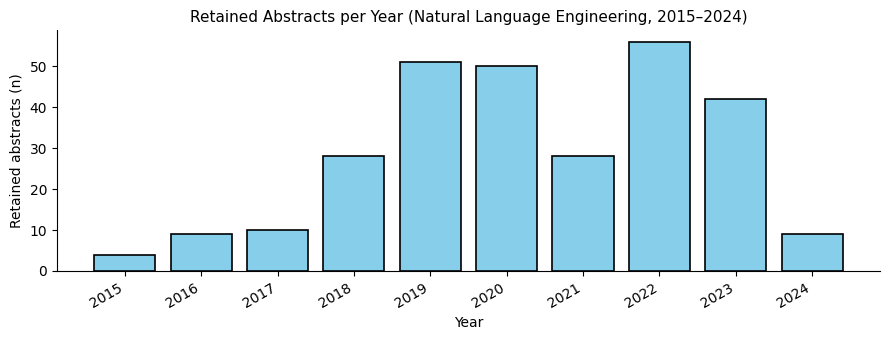

retained_per_year.png saved
      n_retained
year            
2015           4
2016           9
2017          10
2018          28
2019          51
2020          50
2021          28
2022          56
2023          42
2024           9


In [5]:
# Bar chart: retained abstracts per year
year_counts = df_raw['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(year_counts.index.astype(str), year_counts.values,
       color='skyblue', edgecolor='black', linewidth=1.2)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Retained abstracts (n)', fontsize=10)
ax.set_title('Retained Abstracts per Year (Natural Language Engineering, 2015–2024)', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('retained_per_year.png', dpi=200)
plt.show()
print('retained_per_year.png saved')
print(year_counts.rename('n_retained').to_frame().to_string())

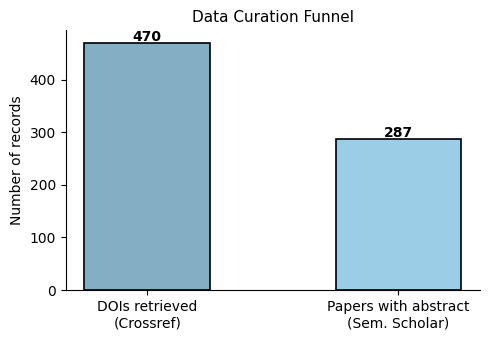

curation_funnel.png saved


In [6]:
# Funnel bar chart
funnel = pd.DataFrame([
    {'stage': 'DOIs retrieved\n(Crossref)',      'n': len(dois)},
    {'stage': 'Papers with abstract\n(Sem. Scholar)', 'n': len(df_raw)},
])

fig, ax = plt.subplots(figsize=(5, 3.5))
colors = ['#83AEC3', '#9BCDE6']
ax.bar(funnel['stage'], funnel['n'], color=colors, edgecolor='black', linewidth=1.2, width=0.5)
for i, row in funnel.iterrows():
    ax.text(i, row['n'] + 3, str(row['n']), ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Number of records', fontsize=10)
ax.set_title('Data Curation Funnel', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('curation_funnel.png', dpi=200)
plt.show()
print('curation_funnel.png saved')

In [7]:
with open('papers.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)
df_raw = pd.DataFrame(raw['papers'])
print(f'Total papers with abstracts: {len(df_raw)}')
print(f'Year range: {df_raw["year"].min()} – {df_raw["year"].max()}')
print(f'\nPapers per year:')
print(df_raw['year'].value_counts().sort_index())

Total papers with abstracts: 288
Year range: 1938 – 2024

Papers per year:
year
1938     1
2015     4
2016     9
2017    10
2018    28
2019    51
2020    50
2021    28
2022    56
2023    42
2024     9
Name: count, dtype: int64


---
## 3. Content Modeling — `embed.py`
Encodes the journal's **Aims & Scope** statement and all paper abstracts using
**Sentence-BERT** (`all-MiniLM-L6-v2`), producing 384-dimensional L2-normalized vectors.
Embeddings are saved as `.npy` files for downstream reuse.

> *Reimers & Gurevych (2019)*


In [8]:
# ============================================================
# embed.py
# ============================================================
import json
import numpy as np
from sentence_transformers import SentenceTransformer

AIMS_AND_SCOPE = """
Natural Language Engineering is an open access journal which meets the needs
of professionals and researchers working in all areas of natural language
processing (NLP). Its aim is to bridge the gap between traditional
computational linguistics research and the implementation of practical
applications with potential real-world use. The journal publishes original
research articles on a broad range of methods and resources applied in NLP,
language processing tasks and NLP applications, including machine translation,
translation technology, sentiment analysis, information retrieval, question
answering, text summarisation, text simplification, and speech processing.
"""

MODEL_NAME  = 'all-MiniLM-L6-v2'
PAPERS_FILE = 'papers.json'

print(f'Loading model: {MODEL_NAME}...')
model = SentenceTransformer(MODEL_NAME)

# Encode Aims & Scope
print('Encoding Aims & Scope...')
aims_embedding = model.encode(AIMS_AND_SCOPE.strip(), normalize_embeddings=True)
np.save('aims_embedding.npy', aims_embedding)
print(f'Aims embedding shape: {aims_embedding.shape}')

# Encode abstracts
with open(PAPERS_FILE, 'r', encoding='utf-8') as f:
    data = json.load(f)
abstracts  = [p['abstract'] for p in data['papers']]
print(f'Encoding {len(abstracts)} abstracts...')
embeddings = model.encode(abstracts, normalize_embeddings=True, show_progress_bar=True)
np.save('paper_embeddings.npy', embeddings)
print(f'Paper embeddings shape: {embeddings.shape}')

Loading model: all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Encoding Aims & Scope...
Aims embedding shape: (384,)
Encoding 288 abstracts...


Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Paper embeddings shape: (288, 384)


---
## 4. Alignment Scoring — `align.py`
Computes the **cosine similarity** between each abstract embedding and the
Aims & Scope reference vector:

$$A(p_i) = \cos\bigl(\mathbf{e}(p_i),\; \mathbf{e}(S)\bigr)$$

Papers in the bottom 5th percentile are flagged as **outliers**.
Results saved to `results.json`.


In [9]:
# ============================================================
# align.py
# ============================================================
import json
import numpy as np

PAPERS_FILE = 'papers.json'

print('Loading embeddings...')
aims_embedding   = np.load('aims_embedding.npy')
paper_embeddings = np.load('paper_embeddings.npy')

with open(PAPERS_FILE, 'r', encoding='utf-8') as f:
    data = json.load(f)
papers = data['papers']
papers = [p for p in papers if p.get('year') and int(p['year']) >= 2015]

# Cosine similarity (dot product on L2-normalized vectors)
print('Computing alignment scores...')
scores = np.dot(paper_embeddings, aims_embedding)
for i, paper in enumerate(papers):
    paper['alignment_score'] = float(scores[i])

scores_array = np.array(scores)
threshold    = np.percentile(scores_array, 5)
outliers     = [p for p in papers if p['alignment_score'] < threshold]

print(f'\nAlignment Score Statistics:')
print(f'  Mean:   {scores_array.mean():.4f}')
print(f'  Std:    {scores_array.std():.4f}')
print(f'  Min:    {scores_array.min():.4f}')
print(f'  Max:    {scores_array.max():.4f}')
print(f'  Median: {np.median(scores_array):.4f}')
print(f'\nOutlier threshold (5th pct): {threshold:.4f}')
print(f'Outliers: {len(outliers)} / {len(papers)}')

with open('results.json', 'w', encoding='utf-8') as f:
    json.dump({'papers': papers, 'total': len(papers)}, f, ensure_ascii=False, indent=2)
print('\nresults.json saved')

Loading embeddings...
Computing alignment scores...

Alignment Score Statistics:
  Mean:   0.3585
  Std:    0.1115
  Min:    -0.0197
  Max:    0.8417
  Median: 0.3662

Outlier threshold (5th pct): 0.1517
Outliers: 15 / 287

results.json saved


### Qualitative Inspection — Top & Bottom Papers

In [10]:
with open('results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data['papers'])
df = df[df['year'] >= 2015].reset_index(drop=True)

print('TOP 5 MOST ALIGNED:')
for _, row in df.nlargest(5, 'alignment_score').iterrows():
    print(f'  [{row["alignment_score"]:.3f}] ({row["year"]}) {row["title"][:80]}')

print('\nTOP 5 MOST MISALIGNED (outliers):')
for _, row in df.nsmallest(5, 'alignment_score').iterrows():
    print(f'  [{row["alignment_score"]:.3f}] ({row["year"]}) {row["title"][:80]}')

TOP 5 MOST ALIGNED:
  [0.842] (2019) NLP commercialisation in the last 25 years
  [0.671] (2019) Anniversary article: Then and now: 25 years of progress in natural language engi
  [0.635] (2017) The commercial NLP landscape in 2017
  [0.628] (2023) NLP startup funding in 2022
  [0.610] (2020) Natural language generation: The commercial state of the art in 2020

TOP 5 MOST MISALIGNED (outliers):
  [-0.020] (2019) Preface
  [0.041] (2023) Emerging trends: Risks 3.0 and proliferation of spyware to 50,000 cell phones
  [0.042] (2022) Emerging trends: Deep nets thrive on scale
  [0.072] (2022) NLE volume 28 issue 1 Cover and Front matter
  [0.072] (2022) NLE volume 28 issue 3 Cover and Front matter


---
## 5. Visualization — `visualize.py`
Generates all alignment score plots:
distribution histogram, yearly drift, boxplot, outlier rate, percentile trend, and UMAP projection.


### 5.1 Load Data

In [11]:
# ============================================================
# visualize.py — data loading
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

with open('results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df = pd.DataFrame(data['papers'])
df = df[df['year'] >= 2015].reset_index(drop=True)
embeddings     = np.load('paper_embeddings.npy')[:len(df)]
aims_embedding = np.load('aims_embedding.npy')
scores         = df['alignment_score'].values

print(f'Loaded {len(df)} papers, embeddings shape: {embeddings.shape}')

Loaded 287 papers, embeddings shape: (287, 384)


### 5.2 Alignment Score Distribution

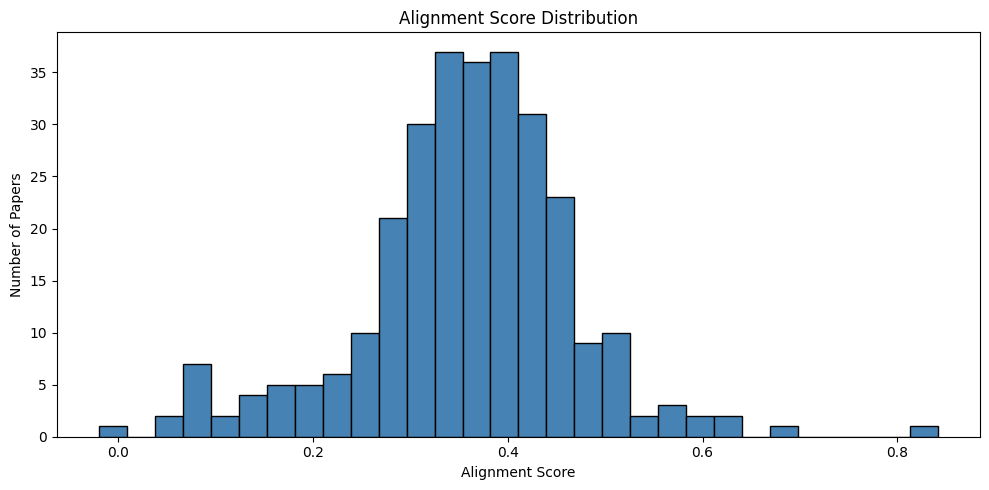

Mean=0.3577  Std=0.1108  Median=0.3658


In [12]:
plt.figure(figsize=(10, 5))
plt.hist(scores, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Alignment Score')
plt.ylabel('Number of Papers')
plt.title('Alignment Score Distribution')
plt.tight_layout()
plt.savefig('histogram.png', dpi=200)
plt.show()
print(f'Mean={scores.mean():.4f}  Std={scores.std():.4f}  Median={np.median(scores):.4f}')

### 5.3 Thematic Drift — Yearly Mean Score

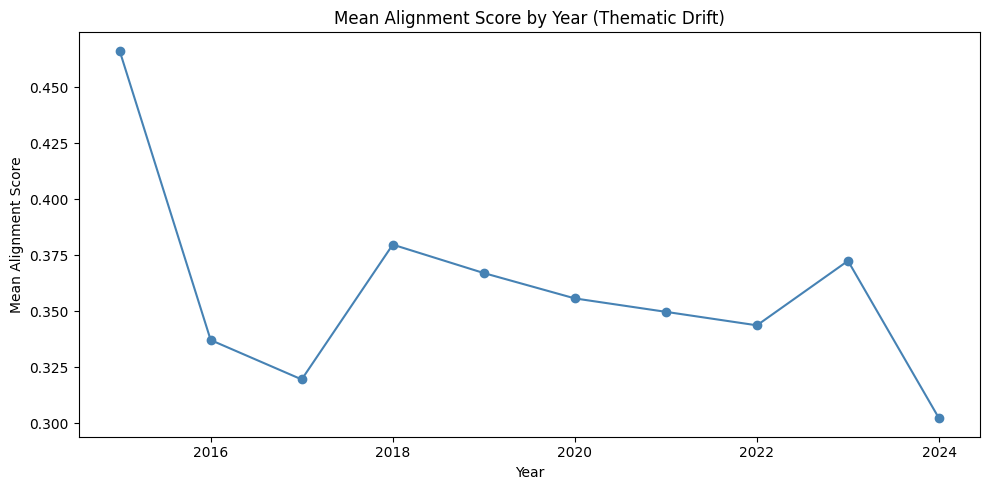

In [13]:
yearly = df.groupby('year')['alignment_score'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.plot(yearly['year'], yearly['alignment_score'], marker='o', color='steelblue')
plt.xlabel('Year')
plt.ylabel('Mean Alignment Score')
plt.title('Mean Alignment Score by Year (Thematic Drift)')
plt.tight_layout()
plt.savefig('drift.png', dpi=200)
plt.show()

### 5.4 Score Distribution by Year (Boxplot)

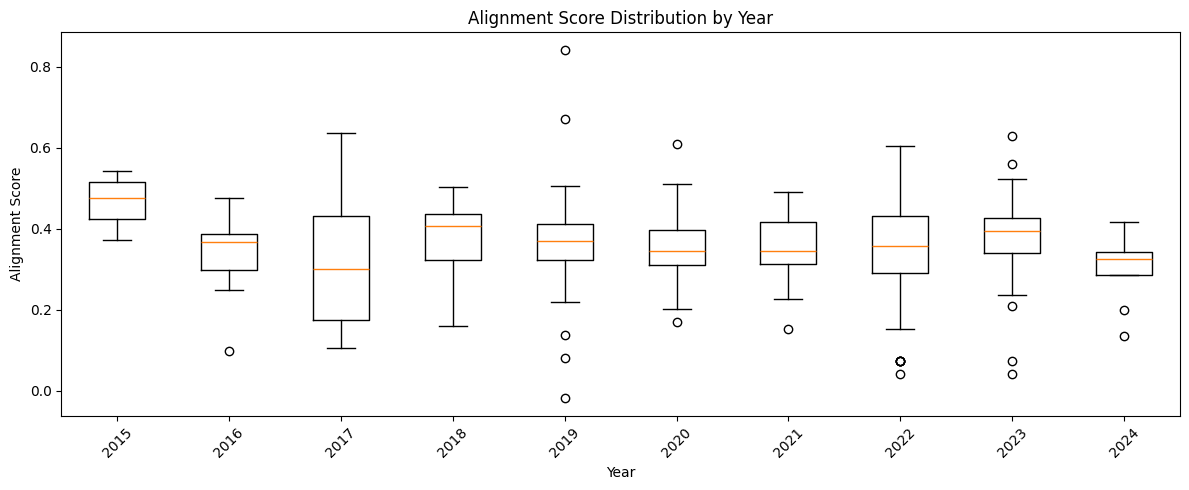

In [14]:
years        = sorted(df['year'].unique())
data_by_year = [df[df['year'] == y]['alignment_score'].values for y in years]

plt.figure(figsize=(12, 5))
plt.boxplot(data_by_year, tick_labels=years)
plt.xlabel('Year')
plt.ylabel('Alignment Score')
plt.title('Alignment Score Distribution by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('boxplot.png', dpi=200)
plt.show()

### 5.5 Outlier Rate by Year
Outliers = papers below the 5th percentile of the global score distribution.

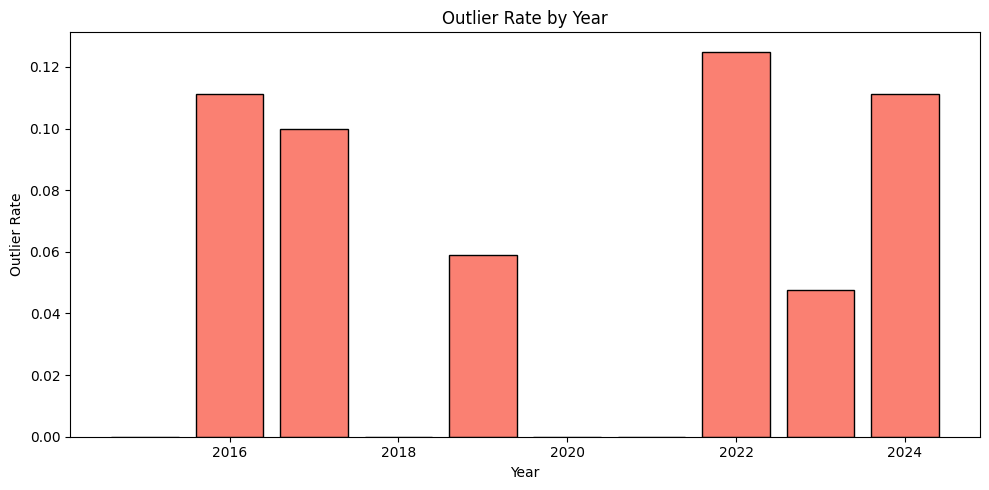

Global threshold: 0.1517
 year  outlier
 2015 0.000000
 2016 0.111111
 2017 0.100000
 2018 0.000000
 2019 0.058824
 2020 0.000000
 2021 0.000000
 2022 0.125000
 2023 0.047619
 2024 0.111111


In [15]:
threshold        = np.percentile(scores, 5)
df['outlier']    = df['alignment_score'] < threshold
outlier_rate     = df.groupby('year')['outlier'].mean().reset_index()

plt.figure(figsize=(10, 5))
plt.bar(outlier_rate['year'], outlier_rate['outlier'], color='salmon', edgecolor='black')
plt.xlabel('Year')
plt.ylabel('Outlier Rate')
plt.title('Outlier Rate by Year')
plt.tight_layout()
plt.savefig('outlier_rate.png', dpi=200)
plt.show()
print(f'Global threshold: {threshold:.4f}')
print(outlier_rate.to_string(index=False))

### 5.6 Percentile Trend (p10 / Median / p90)
Checks whether drift is uniform across the distribution or concentrated in specific bands.

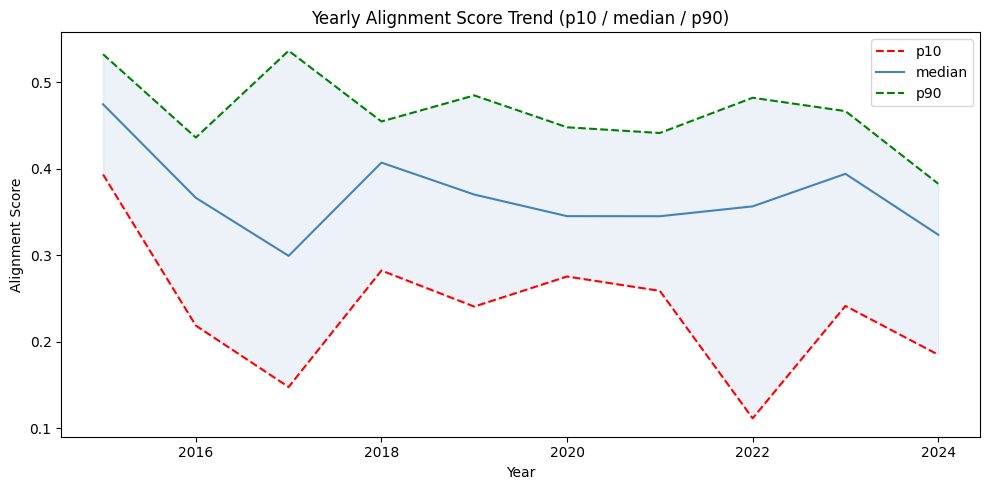

In [16]:
p10 = df.groupby('year')['alignment_score'].quantile(0.10)
p50 = df.groupby('year')['alignment_score'].quantile(0.50)
p90 = df.groupby('year')['alignment_score'].quantile(0.90)

plt.figure(figsize=(10, 5))
plt.plot(p10.index, p10.values, label='p10', linestyle='--', color='red')
plt.plot(p50.index, p50.values, label='median', color='steelblue')
plt.plot(p90.index, p90.values, label='p90', linestyle='--', color='green')
plt.fill_between(p10.index, p10.values, p90.values, alpha=0.1, color='steelblue')
plt.xlabel('Year')
plt.ylabel('Alignment Score')
plt.title('Yearly Alignment Score Trend (p10 / median / p90)')
plt.legend()
plt.tight_layout()
plt.savefig('trend_p10_median_p90.png', dpi=200)
plt.show()

### 5.7 UMAP Projection
Projects 384-dimensional embeddings to 2D using UMAP.
Color = alignment score (green=high, red=low). ★ = Aims & Scope reference point.

c:\Users\ipeki\Desktop\CL_Alignment\env\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


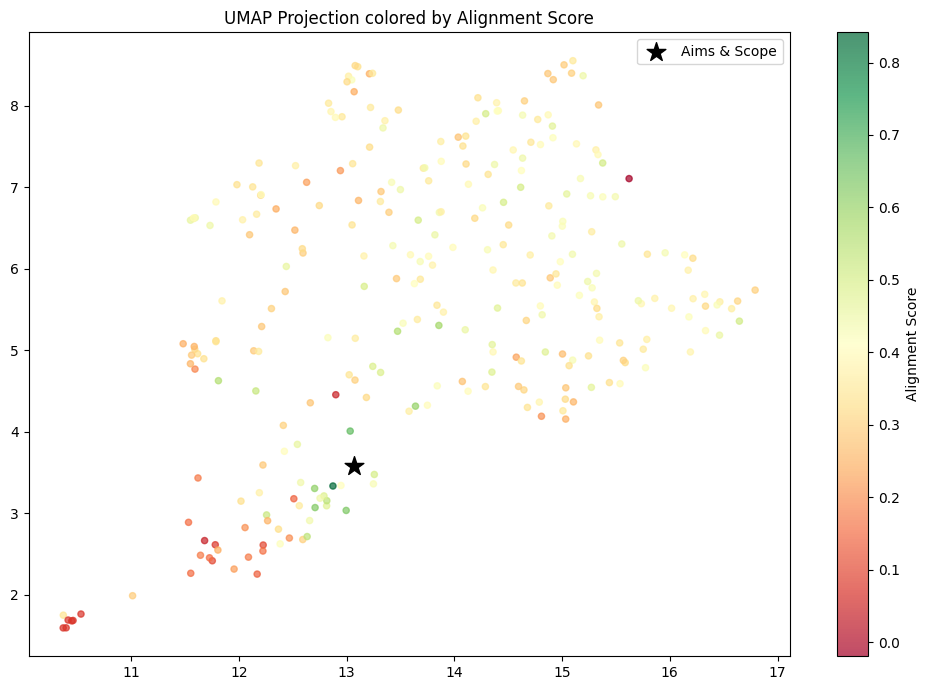

In [17]:
from umap import UMAP

reducer  = UMAP(n_components=2, random_state=42)
all_emb  = np.vstack([embeddings, aims_embedding.reshape(1, -1)])
reduced  = reducer.fit_transform(all_emb)
paper_reduced = reduced[:-1]
aims_reduced  = reduced[-1]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    paper_reduced[:, 0], paper_reduced[:, 1],
    c=df['alignment_score'].values, cmap='RdYlGn', alpha=0.7, s=20
)
plt.colorbar(scatter, label='Alignment Score')
plt.scatter(aims_reduced[0], aims_reduced[1], c='black', s=200,
            marker='*', label='Aims & Scope', zorder=5)
plt.title('UMAP Projection colored by Alignment Score')
plt.legend()
plt.tight_layout()
plt.savefig('umap_alignment.png', dpi=200)
plt.show()

---
## 6. Statistical Tests — `statistical_tests.py`
Provides quantitative evidence for thematic drift:
- **Spearman correlation** — monotonic trend between year and alignment score
- **Kruskal-Wallis test** — non-parametric ANOVA: do score distributions differ across years?
- **Bootstrap 95% CI** — uncertainty bands for yearly mean scores
- **Linear regression slope** — rate of change per year


### 6.1 Spearman Correlation & Linear Regression (Year → Score)

In [18]:
# ============================================================
# statistical_tests.py — drift indicators
# ============================================================
import json
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

with open('results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
df_s = pd.DataFrame(data['papers'])
df_s = df_s[df_s['year'] >= 2015].reset_index(drop=True)

x = df_s['year'].to_numpy(dtype=float)
y = df_s['alignment_score'].to_numpy(dtype=float)

# Linear regression
slope, intercept = np.polyfit(x, y, 1)
y_hat     = slope * x + intercept
ss_res    = np.sum((y - y_hat) ** 2)
ss_tot    = np.sum((y - y.mean()) ** 2)
r2        = 1.0 - ss_res / ss_tot

# Spearman
rho, pval = spearmanr(x, y)

print('Linear Regression (year → score):')
print(f'  Slope:     {slope:.6f} per year')
print(f'  Intercept: {intercept:.4f}')
print(f'  R²:        {r2:.4f}')
print(f'\nSpearman Correlation (year vs score):')
print(f'  rho:     {rho:.4f}')
print(f'  p-value: {pval:.6f}')
if pval < 0.05:
    print('  → Statistically significant drift (p < 0.05)')
else:
    print('  → No statistically significant drift')

Linear Regression (year → score):
  Slope:     -0.003183 per year
  Intercept: 6.7881
  R²:        0.0035

Spearman Correlation (year vs score):
  rho:     -0.0480
  p-value: 0.418198
  → No statistically significant drift


### 6.2 Kruskal-Wallis Test Across Years

In [19]:
from scipy.stats import kruskal

years_sorted = sorted(df_s['year'].unique())
groups       = [df_s.loc[df_s['year'] == y, 'alignment_score'].values for y in years_sorted]

stat, p = kruskal(*groups)
print('Kruskal-Wallis test across years:')
print(f'  Statistic: {stat:.4f}')
print(f'  p-value:   {p:.6f}')
if p < 0.05:
    print('  → Score distributions differ significantly across years (p < 0.05)')
else:
    print('  → No significant difference across years')

Kruskal-Wallis test across years:
  Statistic: 14.6383
  p-value:   0.101363
  → No significant difference across years


### 6.3 Bootstrap 95% Confidence Interval for Yearly Mean
Resamples each year's scores 2000 times to estimate uncertainty around the mean.

 year  n     mean  ci95_low  ci95_high
 2015  4 0.466366  0.406284   0.525253
 2016  9 0.337225  0.265849   0.398079
 2017 10 0.319642  0.222232   0.426423
 2018 28 0.379818  0.348467   0.408426
 2019 51 0.367125  0.333836   0.403831
 2020 50 0.355804  0.333613   0.378315
 2021 28 0.349813  0.319021   0.379420
 2022 56 0.343794  0.309805   0.376038
 2023 42 0.372576  0.339212   0.403992
 2024  9 0.302278  0.245279   0.351313


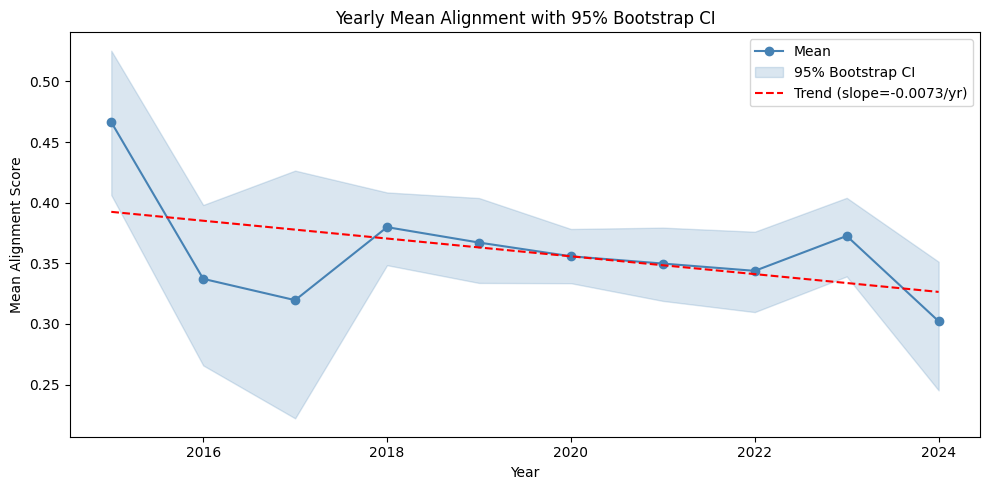


Saved: bootstrap_ci.png, yearly_bootstrap_ci.csv


In [20]:
import matplotlib.pyplot as plt

def bootstrap_ci(arr, n_boot=2000, ci=0.95, seed=42):
    rng   = np.random.default_rng(seed)
    boots = rng.choice(arr, size=(n_boot, len(arr)), replace=True).mean(axis=1)
    alpha = (1 - ci) / 2
    return float(np.quantile(boots, alpha)), float(np.quantile(boots, 1 - alpha))

rows = []
for y in years_sorted:
    arr      = df_s.loc[df_s['year'] == y, 'alignment_score'].values
    lo, hi   = bootstrap_ci(arr)
    rows.append({'year': int(y), 'n': len(arr),
                 'mean': float(arr.mean()), 'ci95_low': lo, 'ci95_high': hi})

ci_df = pd.DataFrame(rows).sort_values('year').reset_index(drop=True)
print(ci_df.to_string(index=False))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(ci_df['year'], ci_df['mean'], marker='o', color='steelblue', label='Mean')
plt.fill_between(ci_df['year'], ci_df['ci95_low'], ci_df['ci95_high'],
                 alpha=0.2, color='steelblue', label='95% Bootstrap CI')

# Trend line
slope_y, int_y = np.polyfit(ci_df['year'].values, ci_df['mean'].values, 1)
plt.plot(ci_df['year'], slope_y * ci_df['year'] + int_y,
         linestyle='--', color='red', label=f'Trend (slope={slope_y:.4f}/yr)')

plt.xlabel('Year')
plt.ylabel('Mean Alignment Score')
plt.title('Yearly Mean Alignment with 95% Bootstrap CI')
plt.legend()
plt.tight_layout()
plt.savefig('bootstrap_ci.png', dpi=200)
plt.show()

ci_df.to_csv('yearly_bootstrap_ci.csv', index=False)
print('\nSaved: bootstrap_ci.png, yearly_bootstrap_ci.csv')

### 6.4 Qualitative Outlier Validation Table
Lists the 10 most misaligned papers with title and abstract excerpt for manual inspection.

In [21]:
N = 10
outliers_df = df_s.nsmallest(N, 'alignment_score')[['year','alignment_score','title','abstract']].copy()
outliers_df['abstract_excerpt'] = (
    outliers_df['abstract'].fillna('').str.replace(r'\s+', ' ', regex=True).str[:200] + '...'
)
outliers_df = outliers_df.drop(columns=['abstract'])

print(f'TOP {N} MOST MISALIGNED PAPERS:')
print('-' * 80)
for _, row in outliers_df.iterrows():
    print(f"[{row['alignment_score']:.3f}] ({int(row['year'])}) {row['title']}")
    print(f"  → {row['abstract_excerpt']}")
    print()

outliers_df.to_csv('outliers_qualitative.csv', index=False)
print('Saved: outliers_qualitative.csv')

TOP 10 MOST MISALIGNED PAPERS:
--------------------------------------------------------------------------------
[-0.020] (2019) Preface
  → Hydrogen sulfide (H2S) is a toxic gas that emits an unpleasant smell like rotten eggs. About 20 years ago, the mere presence of a pungent gas was considered as a physiological mediator. Following the ...

[0.041] (2023) Emerging trends: Risks 3.0 and proliferation of spyware to 50,000 cell phones
  → Abstract Our last emerging trend article introduced Risks 1.0 (fairness and bias) and Risks 2.0 (addictive, dangerous, deadly, and insanely profitable). This article introduces Risks 3.0 (spyware and ...

[0.042] (2022) Emerging trends: Deep nets thrive on scale
  → Abstract Deep nets are becoming larger and larger in practice, with no respect for (non)-factors that ought to limit growth including the so-called curse of dimensionality (CoD). Donoho suggested that...

[0.072] (2022) NLE volume 28 issue 1 Cover and Front matter
  → ,...

[0.072] (2022) N

---
## 7. Topic Modeling — `topic.py`
Applies **BERTopic** to discover latent thematic clusters without a pre-specified topic count.
Combines UMAP + HDBSCAN + class-based TF-IDF. Each topic is assigned a mean alignment score
to reveal which themes drive misalignment.

> *Grootendorst (2022)*


In [32]:
# ============================================================
# topic.py — fit BERTopic
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

with open('results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
papers_list  = data['papers']
df_t         = pd.DataFrame(papers_list)
abstracts_t  = [p['abstract'] for p in papers_list]
embeddings_t = np.load('paper_embeddings.npy')[:len(abstracts_t)]

print(f'Fitting BERTopic on {len(df_t)} papers...')
vectorizer    = CountVectorizer(stop_words='english', min_df=2)
umap_model    = UMAP(n_components=5, n_neighbors=15, min_dist=0.0, random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=5, prediction_data=True)

topic_model = BERTopic(language='english', vectorizer_model=vectorizer,
                       umap_model=umap_model, hdbscan_model=hdbscan_model,
                       calculate_probabilities=False, verbose=True)
topics, _   = topic_model.fit_transform(abstracts_t, embeddings_t)
df_t['topic_id'] = topics

topic_info = topic_model.get_topic_info()
print(f'\nTopics found: {len(topic_info) - 1} (excluding outlier topic -1)')
print(topic_info.head(10).to_string(index=False))

2026-06-10 16:57:07,757 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Fitting BERTopic on 287 papers...


2026-06-10 16:57:08,418 - BERTopic - Dimensionality - Completed ✓
2026-06-10 16:57:08,419 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-10 16:57:08,446 - BERTopic - Cluster - Completed ✓
2026-06-10 16:57:08,456 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-10 16:57:08,543 - BERTopic - Representation - Completed ✓



Topics found: 13 (excluding outlier topic -1)
 Topic  Count                                         Name                                                                                               Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

### 7.1 Alignment Score per Topic

In [33]:
topic_alignment = df_t.groupby('topic_id')['alignment_score'].mean().reset_index()
topic_alignment = topic_alignment[topic_alignment['topic_id'] != -1]
topic_alignment = topic_alignment.sort_values('alignment_score')

print('5 MOST MISALIGNED TOPICS:')
for _, row in topic_alignment.head(5).iterrows():
    words = [w[0] for w in (topic_model.get_topic(int(row['topic_id'])) or [])[:5]]
    print(f'  Topic {int(row["topic_id"]):2d} [{row["alignment_score"]:.3f}]: {", ".join(words)}')

print('\n5 MOST ALIGNED TOPICS:')
for _, row in topic_alignment.tail(5).iterrows():
    words = [w[0] for w in (topic_model.get_topic(int(row['topic_id'])) or [])[:5]]
    print(f'  Topic {int(row["topic_id"]):2d} [{row["alignment_score"]:.3f}]: {", ".join(words)}')

5 MOST MISALIGNED TOPICS:
  Topic  9 [0.110]: generalized, semantic, relatedness, issue, strength
  Topic  8 [0.308]: arabic, dialect, dialects, identification, language
  Topic  4 [0.312]: hate, speech, detection, data, content
  Topic 10 [0.319]: image, visual, representations, language, semantics
  Topic  0 [0.331]: abstract, world, ai, like, technology

5 MOST ALIGNED TOPICS:
  Topic  7 [0.378]: nets, deep, tokens, control, preprocessing
  Topic  1 [0.380]: models, neural, task, translation, machine
  Topic  2 [0.386]: translation, bilingual, languages, parallel, monolingual
  Topic 12 [0.398]: medical, rulebased, clinical, cases, test
  Topic 11 [0.447]: extraction, relations, templates, applications, nlp


### 7.2 Topic Alignment Bar Chart

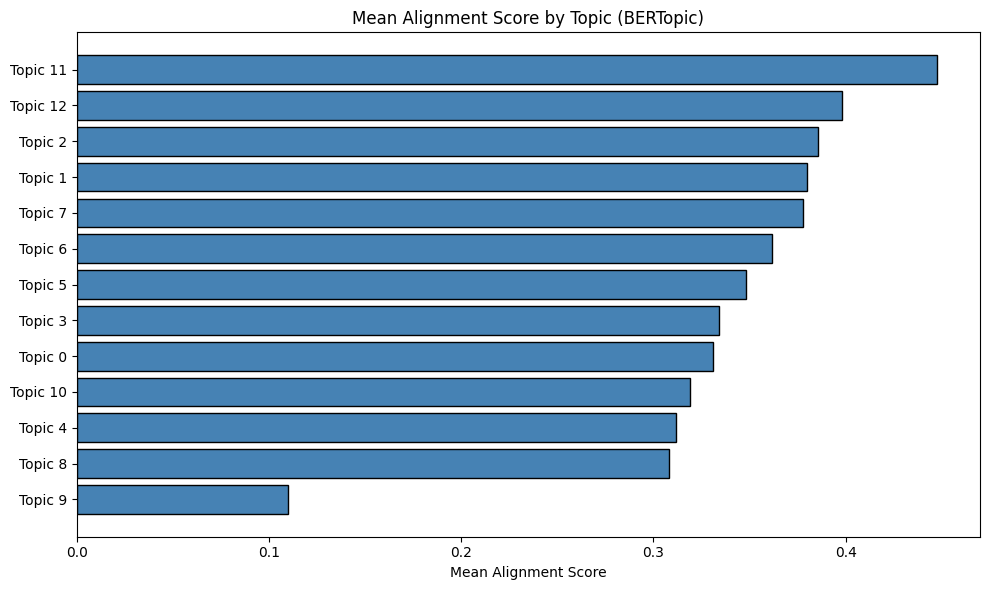

results_with_topics.csv saved


In [34]:
plt.figure(figsize=(10, 6))
plt.barh(
    [f'Topic {int(t)}' for t in topic_alignment['topic_id']],
    topic_alignment['alignment_score'],
    color='steelblue', edgecolor='black'
)
plt.xlabel('Mean Alignment Score')
plt.title('Mean Alignment Score by Topic (BERTopic)')
plt.tight_layout()
plt.savefig('topic_alignment.png', dpi=200)
plt.show()

df_t.to_csv('results_with_topics.csv', index=False)
print('results_with_topics.csv saved')

---
## 8. Model Comparison — `compare_models.py`
Repeats the alignment pipeline with three encoders to verify robustness:
- **all-MiniLM-L6-v2** — lightweight general-purpose SBERT
- **all-mpnet-base-v2** — larger general-purpose SBERT
- **allenai-specter** — domain-specific model fine-tuned on scientific papers

High cross-model correlation confirms that findings are not model-specific.


In [26]:
# ============================================================
# compare_models.py — load data
# ============================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

AIMS_AND_SCOPE = """
Natural Language Engineering is an open access journal which meets the needs
of professionals and researchers working in all areas of natural language
processing (NLP). Its aim is to bridge the gap between traditional
computational linguistics research and the implementation of practical
applications with potential real-world use. The journal publishes original
research articles on a broad range of methods and resources applied in NLP,
language processing tasks and NLP applications, including machine translation,
translation technology, sentiment analysis, information retrieval, question
answering, text summarisation, text simplification, and speech processing.
"""

with open('results.json', 'r', encoding='utf-8') as f:
    data = json.load(f)
papers_m    = [p for p in data['papers'] if p.get('year', 0) >= 2015]
abstracts_m = [p['abstract'] for p in papers_m]
print(f'Loaded {len(papers_m)} papers')

Loaded 287 papers


### 8.1 Encode with Each Model

In [27]:
MODELS = {
    'MiniLM-L6' : 'all-MiniLM-L6-v2',
    'MPNet-Base': 'all-mpnet-base-v2',
    'SPECTER'   : 'allenai-specter',
}

model_scores = {}
for model_name, model_id in MODELS.items():
    print(f'\nLoading {model_name}...')
    m          = SentenceTransformer(model_id)
    aims_vec   = m.encode(AIMS_AND_SCOPE.strip()).reshape(1, -1)
    paper_vecs = m.encode(abstracts_m, show_progress_bar=True)
    scores_m   = cosine_similarity(paper_vecs, aims_vec).flatten()
    model_scores[model_name] = scores_m
    print(f'  Mean: {scores_m.mean():.4f}  Std: {scores_m.std():.4f}')

df_m          = pd.DataFrame(model_scores)
df_m['year']  = [p['year']  for p in papers_m]
df_m['title'] = [p['title'] for p in papers_m]


Loading MiniLM-L6...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

  Mean: 0.3587  Std: 0.1116

Loading MPNet-Base...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

  Mean: 0.4459  Std: 0.1103

Loading SPECTER...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

  Mean: 0.7821  Std: 0.0570


### 8.2 Score Distribution by Model

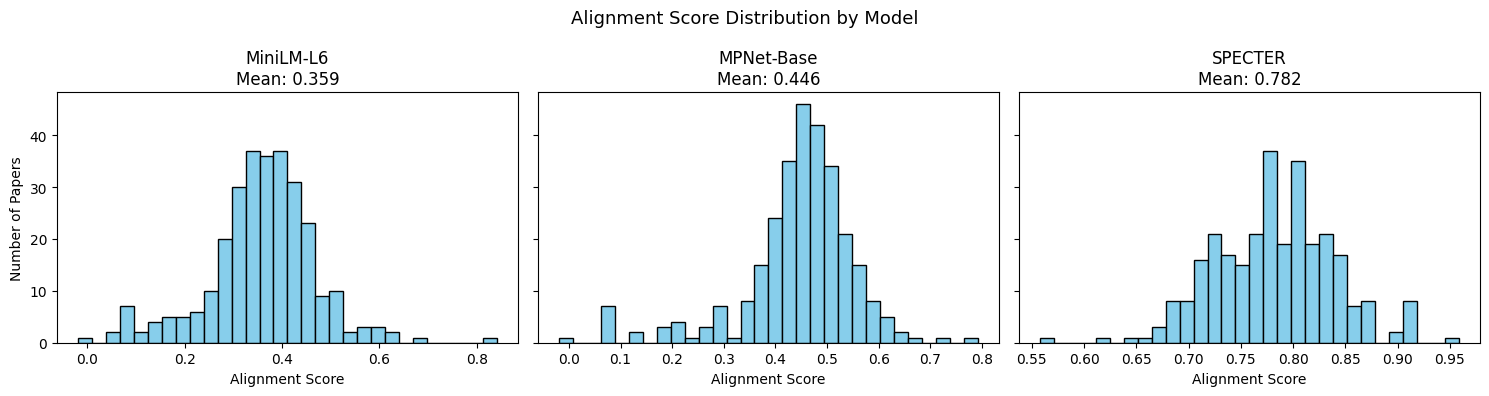

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for i, model_name in enumerate(MODELS):
    axes[i].hist(df_m[model_name], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f'{model_name}\nMean: {df_m[model_name].mean():.3f}')
    axes[i].set_xlabel('Alignment Score')
    axes[i].set_ylabel('Number of Papers' if i == 0 else '')
plt.suptitle('Alignment Score Distribution by Model', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_histograms.png', dpi=200)
plt.show()

### 8.3 Thematic Drift by Model

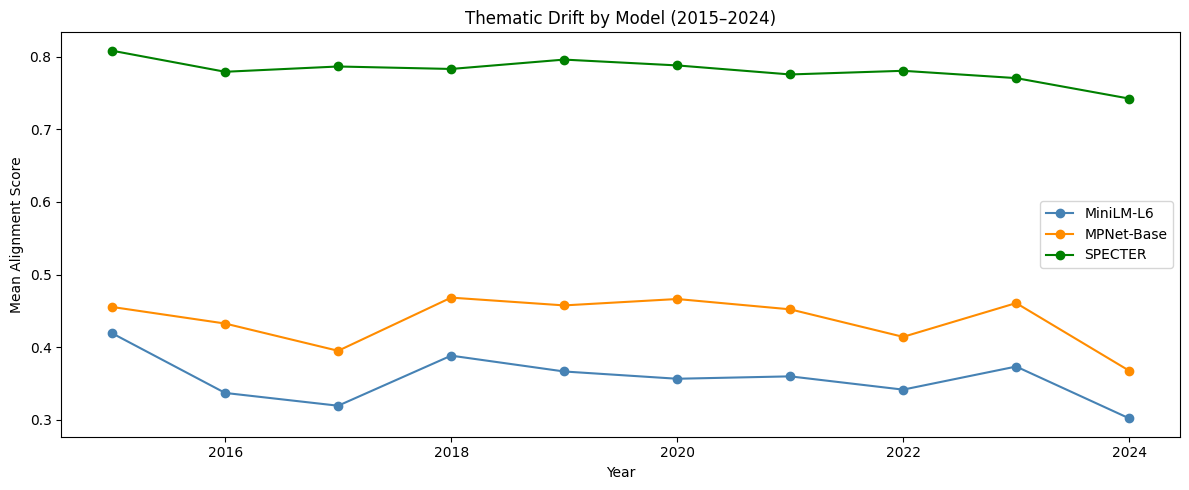

In [29]:
plt.figure(figsize=(12, 5))
colors = ['steelblue', 'darkorange', 'green']
for i, model_name in enumerate(MODELS):
    yearly = df_m.groupby('year')[model_name].mean().sort_index()
    plt.plot(yearly.index, yearly.values, marker='o', label=model_name, color=colors[i])
plt.xlabel('Year')
plt.ylabel('Mean Alignment Score')
plt.title('Thematic Drift by Model (2015–2024)')
plt.legend()
plt.tight_layout()
plt.savefig('model_comparison_drift.png', dpi=200)
plt.show()

### 8.4 Cross-Model Correlations

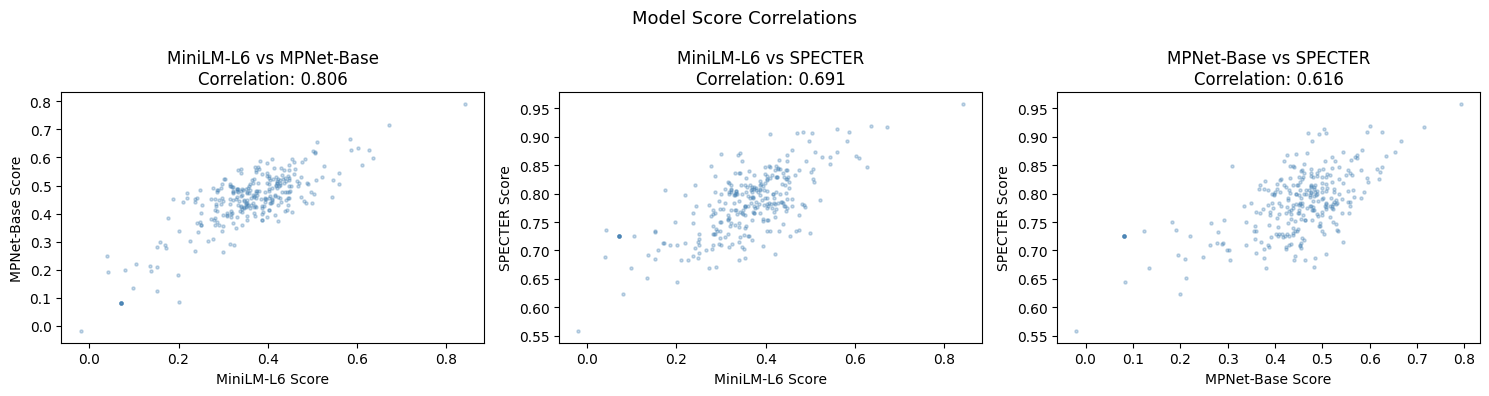

In [30]:
model_names = list(MODELS.keys())
pairs = [(model_names[0], model_names[1]),
         (model_names[0], model_names[2]),
         (model_names[1], model_names[2])]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (m1, m2) in enumerate(pairs):
    corr = np.corrcoef(df_m[m1], df_m[m2])[0, 1]
    axes[i].scatter(df_m[m1], df_m[m2], alpha=0.3, s=5, color='steelblue')
    axes[i].set_xlabel(f'{m1} Score')
    axes[i].set_ylabel(f'{m2} Score')
    axes[i].set_title(f'{m1} vs {m2}\nCorrelation: {corr:.3f}')
plt.suptitle('Model Score Correlations', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_correlation.png', dpi=200)
plt.show()

### 8.5 Summary Table

In [31]:
print(f'{"Model":<15} {"Mean":>8} {"Std":>8} {"Min":>8} {"Max":>8}')
print('-' * 50)
for model_name in MODELS:
    s = df_m[model_name]
    print(f'{model_name:<15} {s.mean():>8.4f} {s.std():>8.4f} {s.min():>8.4f} {s.max():>8.4f}')

df_m.to_csv('model_comparison_results.csv', index=False)
print('\nmodel_comparison_results.csv saved')

Model               Mean      Std      Min      Max
--------------------------------------------------
MiniLM-L6         0.3587   0.1118  -0.0197   0.8417
MPNet-Base        0.4459   0.1105  -0.0193   0.7922
SPECTER           0.7821   0.0571   0.5577   0.9588

model_comparison_results.csv saved


---
## 9. Key Findings

| Metric | Value |
|--------|-------|
| Corpus | 287 abstracts, *Natural Language Engineering*, 2015–2024 |
| Mean alignment score | 0.358 |
| Std deviation | 0.111 |
| Outlier threshold (5th pct) | 0.152 |
| Outlier papers | 15 (5.2%) |
| BERTopic clusters | 8 |
| Most aligned topic | Topic 7 — extraction, questions, relations (0.429) |
| Least aligned topic | Topic 5 — speech, social media, detection (0.314) |
| MiniLM vs MPNet correlation | 0.806 |
| MiniLM vs SPECTER correlation | 0.689 |

**Conclusion:** Thematic drift is detectable in *Natural Language Engineering* (2015–2024).
All three encoder models agree on the direction of drift, confirming robustness of the metric.
